# 02. HELOC Prediction Model

前処理済み HELOC データを用いて分類モデルを学習し、評価結果とモデル artifact を保存します。  
ロジスティック回帰を主対象とし、必要に応じて XGBoost も比較できる構成にしています。


## ライブラリ


In [31]:
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

try:
    import shap
except ImportError:
    shap = None

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)


## パスと共通設定


In [32]:
BASE_DIR_CANDIDATES = [
    Path.cwd(),
    Path.cwd() / "blog" / "01.Counterfactual_Analysis",
    Path("/home/kohei/WorkSpace/blog/01.Counterfactual_Analysis"),
]

BASE_DIR = next(
    (path for path in BASE_DIR_CANDIDATES if (path / "data" / "heloc_feature_metadata.csv").exists()),
    None,
)
if BASE_DIR is None:
    raise FileNotFoundError("HELOC 用の前処理済みデータが見つかりません。01.heloc_preprocess.ipynb の出力を確認してください。")

DATA_DIR = BASE_DIR / "data"
MODEL_DIR = BASE_DIR / "model"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

train_path = DATA_DIR / "train_df.parquet"
test_path = DATA_DIR / "test_df.parquet"
metadata_path = DATA_DIR / "heloc_feature_metadata.csv"
summary_path = DATA_DIR / "heloc_preprocess_summary.json"

target_col = "is_at_risk"
n_splits = 5
random_state = 42


## データとメタ情報のロード


In [33]:
train_df = pd.read_parquet(train_path)
test_df = pd.read_parquet(test_path)
feature_metadata_df = pd.read_csv(metadata_path)
preprocess_summary = json.loads(summary_path.read_text(encoding="utf-8")) if summary_path.exists() else {}

print(f"train shape: {train_df.shape}")
print(f"test shape: {test_df.shape}")
display(train_df.head())
display(feature_metadata_df.head(20))


train shape: (7888, 47)
test shape: (1983, 47)


,average_duration_of_resolution,balance_trade_ratio_log1p,credit_history_length,delinquency_trade_ratio_log1p,delinquency_trade_sum_log1p,estimate_of_risk,estimate_of_risk_is_special_9,high_ratio_bank_share_log1p,illegal_trade_gap,inquiry_pressure_log1p,maximum_illegal_trades,maximum_illegal_trades_over_last_year,months_since_first_trade,months_since_first_trade_is_special_8,months_since_last_illegal_trade_is_special_7,months_since_last_illegal_trade_is_special_8,months_since_last_illegal_trade_log1p,months_since_last_inquiry_not_recent_is_special_7,months_since_last_inquiry_not_recent_is_special_8,months_since_last_inquiry_not_recent_log1p,months_since_last_trade_log1p,net_fraction_of_installment_burden,net_fraction_of_installment_burden_is_special_8,net_fraction_of_revolving_burden,net_fraction_of_revolving_burden_is_special_8,nr_banks_with_high_ratio_is_special_8,nr_banks_with_high_ratio_log1p,nr_inquiries_in_last_6_months_log1p,nr_inquiries_in_last_6_months_not_recent_log1p,nr_installment_trades_with_balance_is_special_8,nr_installment_trades_with_balance_log1p,nr_revolving_trades_with_balance_is_special_8,nr_revolving_trades_with_balance_log1p,nr_total_trades,nr_trades_initiated_in_last_year_log1p,nr_trades_insolvent_for_over_60_days_log1p,nr_trades_insolvent_for_over_90_days_log1p,number_of_satisfactory_trades,percentage_of_installment_trades,percentage_of_legal_trades,percentage_trades_with_balance,percentage_trades_with_balance_is_special_8,recent_activity_gap,recent_inquiry_share,revolving_installment_burden_gap,satisfactory_trade_ratio_log1p,is_at_risk
0,63.0,0.374693,136.0,0.0,0.0,80.0,0,0.000000,0.0,0.087011,6.0,6.0,136.0,0,0,0,3.091042,1,0,0.000000,2.772589,54.0,0,19.0,0,0,0.000000,0.693147,0.693147,0,1.386294,0,1.098612,11.0,0.0,0.0,0.0,11.0,36.0,91.0,71.0,0,121.0,1.0,-35.0,0.693147,0
1,130.0,0.251314,342.0,0.0,0.0,91.0,0,0.000000,1.0,0.000000,8.0,7.0,342.0,0,1,0,0.000000,0,1,0.000000,3.761200,74.0,1,3.0,0,0,0.000000,0.000000,0.000000,0,1.098612,0,1.098612,14.0,0.0,0.0,0.0,14.0,36.0,100.0,50.0,0,300.0,0.0,-71.0,0.693147,0
2,88.0,0.361013,193.0,0.0,0.0,56.0,0,0.160343,2.0,0.042560,6.0,4.0,193.0,0,0,0,1.386294,0,0,0.000000,3.850148,37.0,0,64.0,0,0,1.609438,0.693147,0.693147,0,1.098612,0,2.197225,23.0,0.0,0.0,0.0,22.0,22.0,78.0,83.0,0,147.0,1.0,27.0,0.671168,1
3,76.0,0.356675,250.0,0.0,0.0,63.0,0,0.000000,2.0,0.133531,6.0,4.0,250.0,0,0,0,0.693147,0,0,0.000000,3.332205,11.0,0,36.0,0,0,0.000000,1.098612,1.098612,0,0.693147,0,1.791759,14.0,0.0,0.0,0.0,12.0,17.0,75.0,75.0,0,223.0,1.0,25.0,0.619039,1
4,60.0,0.295464,255.0,0.0,0.0,72.0,0,0.247836,1.0,0.000000,8.0,7.0,255.0,0,1,0,0.000000,0,0,2.639057,2.639057,14.0,0,85.0,0,0,2.302585,0.000000,0.000000,0,1.098612,0,2.302585,32.0,0.0,0.0,0.0,31.0,22.0,100.0,79.0,0,242.0,0.0,71.0,0.677399,1


,feature,role,dtype,description,in_model_features
0,average_duration_of_resolution,base_numeric,float64,口座や取引の平均継続期間を表す指標です。,True
1,balance_trade_ratio_log1p,log_numeric,float64,balance_trade_ratio に対して log1p 変換を適用した列。,True
2,credit_history_length,derived_numeric,float64,初回取引からの経過月数。,True
3,delinquency_trade_ratio_log1p,log_numeric,float64,delinquency_trade_ratio に対して log1p 変換を適用した列。,True
4,delinquency_trade_sum_log1p,log_numeric,float64,delinquency_trade_sum に対して log1p 変換を適用した列。,True
5,estimate_of_risk,base_numeric,float64,申込者の信用リスクの推定スコア。大きいほど低リスク寄りと解釈されることが多いです。,True
6,estimate_of_risk_is_special_9,special_value_flag,int64,estimate_of_risk が特殊値 -9 を持っていたことを表すフラグ。意味: 信用...,True
7,high_ratio_bank_share_log1p,log_numeric,float64,high_ratio_bank_share に対して log1p 変換を適用した列。,True
8,illegal_trade_gap,derived_numeric,float64,全期間の問題取引最大件数と過去1年の最大件数の差。,True
9,inquiry_pressure_log1p,log_numeric,float64,inquiry_pressure に対して log1p 変換を適用した列。,True


## 学習対象列の整理


In [34]:
if target_col not in train_df.columns or target_col not in test_df.columns:
    raise ValueError(f"{target_col} must exist in both train_df and test_df.")

metadata_feature_cols = feature_metadata_df.loc[
    feature_metadata_df["in_model_features"] & (feature_metadata_df["feature"] != target_col),
    "feature",
].tolist()

feature_cols = [col for col in metadata_feature_cols if col in train_df.columns and col in test_df.columns]
missing_metadata_cols = sorted(set(metadata_feature_cols) - set(feature_cols))
unexpected_train_cols = sorted(set(train_df.columns) - set(feature_cols) - {target_col})

if missing_metadata_cols:
    raise ValueError(f"metadata にあるが train/test に存在しない列があります: {missing_metadata_cols}")

X_train_full = train_df[feature_cols].copy()
y_train_full_raw = train_df[target_col].copy()
X_test = test_df[feature_cols].copy()
y_test_raw = test_df[target_col].copy()

non_numeric_cols = X_train_full.select_dtypes(exclude=["number", "bool"]).columns.tolist()
if non_numeric_cols:
    raise ValueError(f"Non-numeric columns remain after preprocessing: {non_numeric_cols}")

label_encoder = LabelEncoder()
label_encoder.fit(y_train_full_raw)
y_train_full = label_encoder.transform(y_train_full_raw)
y_test = label_encoder.transform(y_test_raw)

cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
class_names = [str(label) for label in label_encoder.classes_]
positive_class_label = label_encoder.classes_[1]

print(f"number of features: {len(feature_cols)}")
print(f"positive class label: {positive_class_label}")
print(f"unexpected extra columns in train_df: {unexpected_train_cols}")
print("train target distribution:")
display(y_train_full_raw.value_counts(normalize=True).rename("ratio"))
print("test target distribution:")
display(y_test_raw.value_counts(normalize=True).rename("ratio"))


number of features: 46
positive class label: 1
unexpected extra columns in train_df: []
train target distribution:


is_at_risk
1    0.520157
0    0.479843
Name: ratio, dtype: float64

test target distribution:


is_at_risk
1    0.520928
0    0.479072
Name: ratio, dtype: float64

## ロジスティック回帰用スケーリング


In [35]:
scaler = StandardScaler()

X_train_full_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_full),
    columns=feature_cols,
    index=X_train_full.index,
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols,
    index=X_test.index,
)

display(X_train_full_scaled.head())


,average_duration_of_resolution,balance_trade_ratio_log1p,credit_history_length,delinquency_trade_ratio_log1p,delinquency_trade_sum_log1p,estimate_of_risk,estimate_of_risk_is_special_9,high_ratio_bank_share_log1p,illegal_trade_gap,inquiry_pressure_log1p,maximum_illegal_trades,maximum_illegal_trades_over_last_year,months_since_first_trade,months_since_first_trade_is_special_8,months_since_last_illegal_trade_is_special_7,months_since_last_illegal_trade_is_special_8,months_since_last_illegal_trade_log1p,months_since_last_inquiry_not_recent_is_special_7,months_since_last_inquiry_not_recent_is_special_8,months_since_last_inquiry_not_recent_log1p,months_since_last_trade_log1p,net_fraction_of_installment_burden,net_fraction_of_installment_burden_is_special_8,net_fraction_of_revolving_burden,net_fraction_of_revolving_burden_is_special_8,nr_banks_with_high_ratio_is_special_8,nr_banks_with_high_ratio_log1p,nr_inquiries_in_last_6_months_log1p,nr_inquiries_in_last_6_months_not_recent_log1p,nr_installment_trades_with_balance_is_special_8,nr_installment_trades_with_balance_log1p,nr_revolving_trades_with_balance_is_special_8,nr_revolving_trades_with_balance_log1p,nr_total_trades,nr_trades_initiated_in_last_year_log1p,nr_trades_insolvent_for_over_60_days_log1p,nr_trades_insolvent_for_over_90_days_log1p,number_of_satisfactory_trades,percentage_of_installment_trades,percentage_of_legal_trades,percentage_trades_with_balance,percentage_trades_with_balance_is_special_8,recent_activity_gap,recent_inquiry_share,revolving_installment_burden_gap,satisfactory_trade_ratio_log1p
0,-0.465869,0.401427,-0.668427,-0.412545,-0.612319,0.807761,-0.029803,-0.621980,-0.393398,0.059064,-0.198891,0.150553,-0.668427,-0.155829,-0.943289,-0.132948,1.141651,2.101805,-0.230821,-0.575205,0.957143,-0.821248,-0.727309,-0.554344,-0.13923,-0.247702,-0.976518,0.049887,0.084091,-0.309613,0.606207,-0.126894,-0.657670,-0.900556,-1.388521,-0.607899,-0.497422,-0.898080,0.077185,-0.110719,0.202622,-0.04063,-0.728828,0.877928,0.015248,0.115666
1,1.500852,-0.210659,1.466063,-0.412545,-0.612319,1.921361,-0.029803,-0.621980,0.245499,-0.525862,0.881586,0.758622,1.466063,-0.155829,1.060121,-0.132948,-0.887274,-0.475782,4.332369,-0.575205,2.154479,0.183600,1.374931,-1.114965,-0.13923,-0.247702,-0.976518,-1.023253,-0.996369,-0.309613,-0.159396,-0.126894,-0.657670,-0.668479,-1.388521,-0.607899,-0.497422,-0.631899,0.077185,0.649379,-0.755717,-0.04063,1.136434,-1.170794,-1.030631,0.115666
2,0.267982,0.333559,-0.077816,-0.412545,-0.612319,-1.621913,-0.029803,1.116451,0.884397,-0.239759,-0.198891,-1.065585,-0.077816,-0.155829,-0.943289,-0.132948,0.022674,-0.475782,-0.230821,-0.575205,2.262206,-1.675369,-0.727309,1.022402,-0.13923,-0.247702,1.868730,0.049887,0.084091,-0.309613,-0.159396,-0.126894,1.272779,0.027754,-1.388521,-0.607899,-0.497422,0.077917,-0.702798,-1.208640,0.750244,-0.04063,-0.457896,0.877928,1.816484,0.024299
3,-0.084266,0.312036,0.512796,-0.412545,-0.612319,-0.913258,-0.029803,-0.621980,0.884397,0.371790,-0.198891,-1.065585,0.512796,-0.155829,-0.943289,-0.132948,-0.432300,-0.475782,-0.230821,-0.575205,1.634910,-2.981671,-0.727309,0.041315,-0.13923,-0.247702,-0.976518,0.677633,0.716119,-0.309613,-1.238452,-0.126894,0.560308,-0.668479,-1.388521,-0.607899,-0.497422,-0.809353,-0.981363,-1.462006,0.385162,-0.04063,0.334058,0.877928,1.758379,-0.192402
4,-0.553931,0.008369,0.564604,-0.412545,-0.612319,-0.002130,-0.029803,2.065053,0.245499,-0.525862,0.881586,0.758622,0.564604,-0.155829,1.060121,-0.132948,-0.887274,-0.475782,-0.230821,2.406952,0.795419,-2.830944,-0.727309,1.758217,-0.13923,-0.247702,3.094111,-1.023253,-0.996369,-0.309613,-0.159396,-0.126894,1.457915,0.723987,-1.388521,-0.607899,-0.497422,0.876461,-0.702798,0.649379,0.567703,-0.04063,0.532047,-1.170794,3.094780,0.050200


## ロジスティック回帰の閾値探索


In [36]:
threshold_grid = np.round(np.arange(0.05, 0.96, 0.01), 2)
cv_metric_rows = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(X_train_full, y_train_full), start=1):
    X_train_fold = X_train_full.iloc[train_idx]
    X_valid_fold = X_train_full.iloc[valid_idx]
    y_train_fold = y_train_full[train_idx]
    y_valid_fold = y_train_full[valid_idx]

    fold_scaler = StandardScaler()
    X_train_fold_scaled = fold_scaler.fit_transform(X_train_fold)
    X_valid_fold_scaled = fold_scaler.transform(X_valid_fold)

    fold_model = LogisticRegression(max_iter=2000, random_state=random_state)
    fold_model.fit(X_train_fold_scaled, y_train_fold)

    fold_valid_pred_proba = fold_model.predict_proba(X_valid_fold_scaled)[:, 1]

    for threshold in threshold_grid:
        fold_valid_pred = (fold_valid_pred_proba >= threshold).astype(int)
        cv_metric_rows.append(
            {
                "fold": fold,
                "threshold": threshold,
                "accuracy": accuracy_score(y_valid_fold, fold_valid_pred),
                "precision": precision_score(y_valid_fold, fold_valid_pred, zero_division=0),
                "recall": recall_score(y_valid_fold, fold_valid_pred, zero_division=0),
                "f1": f1_score(y_valid_fold, fold_valid_pred, zero_division=0),
            }
        )

cv_metrics_df = pd.DataFrame(cv_metric_rows)
logistic_threshold_candidates = (
    cv_metrics_df.groupby("threshold", as_index=False)
    .agg(
        accuracy=("accuracy", "mean"),
        precision=("precision", "mean"),
        recall=("recall", "mean"),
        f1=("f1", "mean"),
        f1_std=("f1", "std"),
    )
    .sort_values(["f1", "threshold"], ascending=[False, True])
    .reset_index(drop=True)
)

logistic_best_threshold = (
    logistic_threshold_candidates.iloc[0]["threshold"]
    if not logistic_threshold_candidates.empty else 0.5
)

print(f"selected threshold from {n_splits}-fold mean f1: {logistic_best_threshold:.4f}")
display(logistic_threshold_candidates.head(10))


selected threshold from 5-fold mean f1: 0.3700


,threshold,accuracy,precision,recall,f1,f1_std
0,0.37,0.724013,0.685680,0.867172,0.765700,0.008827
1,0.36,0.721985,0.681742,0.873509,0.765692,0.008856
2,0.38,0.725915,0.689629,0.860592,0.765564,0.008716
3,0.34,0.717041,0.672919,0.887888,0.765480,0.008416
4,0.35,0.719069,0.676706,0.881064,0.765371,0.008303
5,0.33,0.713110,0.667693,0.893250,0.764047,0.008761
6,0.39,0.726802,0.693713,0.850355,0.763997,0.008124
7,0.40,0.728957,0.698759,0.842068,0.763647,0.009870
8,0.41,0.730985,0.703276,0.835487,0.763597,0.007476
9,0.42,0.733013,0.708547,0.827201,0.763161,0.007877


## ロジスティック回帰の学習と評価


In [37]:
logistic_model = LogisticRegression(max_iter=2000, random_state=random_state)
logistic_model.fit(X_train_full_scaled, y_train_full)

logistic_test_pred_proba = logistic_model.predict_proba(X_test_scaled)[:, 1]
logistic_test_pred = (logistic_test_pred_proba >= logistic_best_threshold).astype(int)

logistic_metrics = {
    "accuracy": accuracy_score(y_test, logistic_test_pred),
    "precision": precision_score(y_test, logistic_test_pred, zero_division=0),
    "recall": recall_score(y_test, logistic_test_pred, zero_division=0),
    "f1": f1_score(y_test, logistic_test_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, logistic_test_pred_proba),
}
logistic_metrics_df = pd.DataFrame(logistic_metrics, index=["test"]).T.rename(columns={"test": "value"})
display(logistic_metrics_df)


,value
accuracy,0.711548
precision,0.676899
recall,0.853824
f1,0.755137
roc_auc,0.800811


,0,1
0,529,421
1,151,882


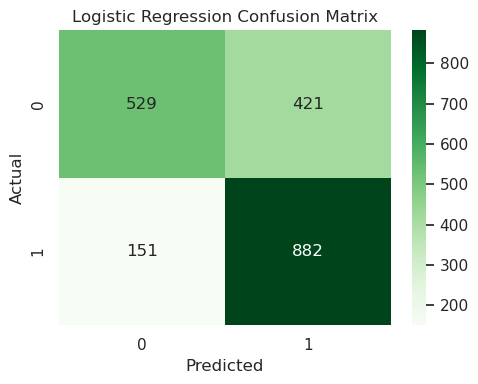

In [38]:
logistic_cm = confusion_matrix(y_test, logistic_test_pred)
logistic_cm_df = pd.DataFrame(logistic_cm, index=class_names, columns=class_names)
display(logistic_cm_df)

plt.figure(figsize=(5, 4))
sns.heatmap(logistic_cm_df, annot=True, fmt="d", cmap="Greens")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [39]:
logistic_prediction_result = X_test.copy()
logistic_prediction_result["actual"] = y_test_raw.values
logistic_prediction_result["prediction"] = label_encoder.inverse_transform(logistic_test_pred)
logistic_prediction_result["prediction_proba"] = logistic_test_pred_proba

display(logistic_prediction_result.head())


,average_duration_of_resolution,balance_trade_ratio_log1p,credit_history_length,delinquency_trade_ratio_log1p,delinquency_trade_sum_log1p,estimate_of_risk,estimate_of_risk_is_special_9,high_ratio_bank_share_log1p,illegal_trade_gap,inquiry_pressure_log1p,maximum_illegal_trades,maximum_illegal_trades_over_last_year,months_since_first_trade,months_since_first_trade_is_special_8,months_since_last_illegal_trade_is_special_7,months_since_last_illegal_trade_is_special_8,months_since_last_illegal_trade_log1p,months_since_last_inquiry_not_recent_is_special_7,months_since_last_inquiry_not_recent_is_special_8,months_since_last_inquiry_not_recent_log1p,months_since_last_trade_log1p,net_fraction_of_installment_burden,net_fraction_of_installment_burden_is_special_8,net_fraction_of_revolving_burden,net_fraction_of_revolving_burden_is_special_8,nr_banks_with_high_ratio_is_special_8,nr_banks_with_high_ratio_log1p,nr_inquiries_in_last_6_months_log1p,nr_inquiries_in_last_6_months_not_recent_log1p,nr_installment_trades_with_balance_is_special_8,nr_installment_trades_with_balance_log1p,nr_revolving_trades_with_balance_is_special_8,nr_revolving_trades_with_balance_log1p,nr_total_trades,nr_trades_initiated_in_last_year_log1p,nr_trades_insolvent_for_over_60_days_log1p,nr_trades_insolvent_for_over_90_days_log1p,number_of_satisfactory_trades,percentage_of_installment_trades,percentage_of_legal_trades,percentage_trades_with_balance,percentage_trades_with_balance_is_special_8,recent_activity_gap,recent_inquiry_share,revolving_installment_burden_gap,satisfactory_trade_ratio_log1p,actual,prediction,prediction_proba
0,73.0,0.287682,162.0,0.287682,1.098612,51.0,0,0.000000,2.0,0.000000,4.0,2.0,162.0,0,0,0,0.693147,0,0,0.00000,3.583519,11.0,0,43.0,0,0,0.000000,0.000000,0.000000,0,0.693147,0,0.693147,6.0,0.000000,0.693147,0.693147,4.0,33.0,50.0,50.0,0,127.0,0.0,32.0,0.510826,1,1,0.933806
1,111.0,0.092373,364.0,0.000000,0.000000,79.0,0,0.031749,1.0,0.000000,8.0,7.0,364.0,0,1,0,0.000000,0,1,0.00000,3.583519,51.0,0,93.0,0,0,0.693147,0.000000,0.000000,0,1.098612,0,0.693147,31.0,0.000000,0.000000,0.000000,22.0,27.0,100.0,75.0,0,329.0,0.0,42.0,0.536305,0,0,0.167504
2,84.0,0.274437,199.0,0.100083,1.098612,72.0,0,0.000000,-4.0,0.146603,2.0,6.0,199.0,0,0,0,3.583519,0,0,0.00000,0.000000,74.0,1,10.0,0,0,0.000000,1.386294,1.386294,1,1.098612,0,1.609438,19.0,1.386294,0.693147,0.693147,15.0,47.0,94.0,56.0,0,199.0,1.0,-64.0,0.581922,0,1,0.575199
3,91.0,0.133531,275.0,0.000000,0.000000,79.0,0,0.000000,2.0,0.000000,6.0,4.0,275.0,0,0,0,1.945910,0,0,1.94591,0.000000,74.0,1,0.0,0,0,0.000000,0.000000,0.000000,0,0.693147,0,0.693147,14.0,1.386294,0.000000,0.000000,13.0,29.0,86.0,33.0,0,275.0,0.0,-74.0,0.656780,0,0,0.270385
4,109.0,0.336472,264.0,0.000000,0.000000,61.0,0,0.205852,0.0,0.028171,6.0,6.0,264.0,0,0,0,2.564949,0,0,0.00000,3.496508,74.0,0,86.0,0,0,2.197225,0.693147,0.693147,0,1.386294,0,2.484907,35.0,0.000000,0.000000,0.000000,30.0,37.0,97.0,93.0,0,232.0,1.0,12.0,0.619039,1,1,0.813662


## ロジスティック回帰の係数確認


,feature,coefficient,abs_coefficient,role,description
0,recent_activity_gap,-0.651278,0.651278,derived_numeric,初回取引からの経過月数と直近取引からの経過月数の差。最近どれだけ取引活動があったかを表す指標。
1,months_since_last_illegal_trade_is_special_7,-0.540515,0.540515,special_value_flag,months_since_last_illegal_trade が特殊値 -7 を持っていた...
2,delinquency_trade_sum_log1p,0.420266,0.420266,log_numeric,delinquency_trade_sum に対して log1p 変換を適用した列。
3,estimate_of_risk,-0.358700,0.358700,base_numeric,申込者の信用リスクの推定スコア。大きいほど低リスク寄りと解釈されることが多いです。
4,months_since_last_inquiry_not_recent_log1p,-0.314362,0.314362,log_numeric,months_since_last_inquiry_not_recent に対して log1...
5,months_since_last_illegal_trade_log1p,-0.304009,0.304009,log_numeric,months_since_last_illegal_trade に対して log1p 変換を...
6,months_since_last_inquiry_not_recent_is_special_8,-0.303935,0.303935,special_value_flag,months_since_last_inquiry_not_recent が特殊値 -8 を...
7,credit_history_length,0.301845,0.301845,derived_numeric,初回取引からの経過月数。
8,months_since_first_trade,0.301845,0.301845,base_numeric,最初の信用取引を開始してからの経過月数。信用履歴の長さを表します。
9,nr_inquiries_in_last_6_months_log1p,0.294425,0.294425,log_numeric,nr_inquiries_in_last_6_months に対して log1p 変換を適用...


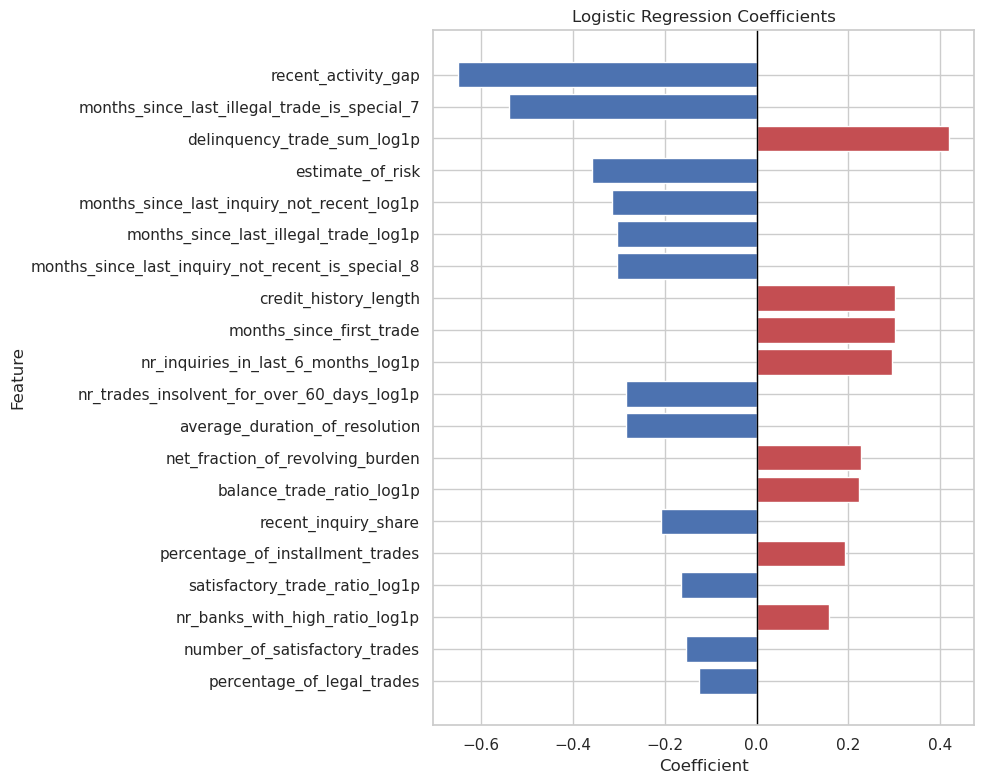

In [40]:
logistic_coef_df = (
    pd.DataFrame({"feature": feature_cols, "coefficient": logistic_model.coef_.ravel()})
    .assign(abs_coefficient=lambda df_: df_["coefficient"].abs())
    .merge(feature_metadata_df[["feature", "role", "description"]], on="feature", how="left")
    .sort_values("abs_coefficient", ascending=False)
    .reset_index(drop=True)
)

display(logistic_coef_df.head(20))

plot_coef_df = logistic_coef_df.head(20)
plot_colors = ["#c44e52" if coef > 0 else "#4c72b0" for coef in plot_coef_df["coefficient"]]

plt.figure(figsize=(10, 8))
plt.barh(plot_coef_df["feature"], plot_coef_df["coefficient"], color=plot_colors)
plt.axvline(0, color="black", linewidth=1)
plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## XGBoost の閾値探索


In [41]:
if XGBClassifier is None:
    raise ImportError("xgboost is not installed. Install xgboost in this kernel before running the XGBoost section.")

xgb_threshold_grid = threshold_grid.copy()
xgb_cv_metric_rows = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(X_train_full, y_train_full), start=1):
    X_train_fold = X_train_full.iloc[train_idx]
    X_valid_fold = X_train_full.iloc[valid_idx]
    y_train_fold = y_train_full[train_idx]
    y_valid_fold = y_train_full[valid_idx]

    fold_model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        min_child_weight=1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=random_state,
        n_jobs=-1,
    )
    fold_model.fit(X_train_fold, y_train_fold)

    fold_valid_pred_proba = fold_model.predict_proba(X_valid_fold)[:, 1]

    for threshold in xgb_threshold_grid:
        fold_valid_pred = (fold_valid_pred_proba >= threshold).astype(int)
        xgb_cv_metric_rows.append(
            {
                "fold": fold,
                "threshold": threshold,
                "accuracy": accuracy_score(y_valid_fold, fold_valid_pred),
                "precision": precision_score(y_valid_fold, fold_valid_pred, zero_division=0),
                "recall": recall_score(y_valid_fold, fold_valid_pred, zero_division=0),
                "f1": f1_score(y_valid_fold, fold_valid_pred, zero_division=0),
            }
        )

xgb_cv_metrics_df = pd.DataFrame(xgb_cv_metric_rows)
xgb_threshold_candidates = (
    xgb_cv_metrics_df.groupby("threshold", as_index=False)
    .agg(
        accuracy=("accuracy", "mean"),
        precision=("precision", "mean"),
        recall=("recall", "mean"),
        f1=("f1", "mean"),
        f1_std=("f1", "std"),
    )
    .sort_values(["f1", "threshold"], ascending=[False, True])
    .reset_index(drop=True)
)

xgb_best_threshold = xgb_threshold_candidates.iloc[0]["threshold"] if not xgb_threshold_candidates.empty else 0.5

print(f"selected XGBoost threshold from {n_splits}-fold mean f1: {xgb_best_threshold:.4f}")
display(xgb_threshold_candidates.head(10))


selected XGBoost threshold from 5-fold mean f1: 0.3800


,threshold,accuracy,precision,recall,f1,f1_std
0,0.38,0.730096,0.698796,0.846211,0.765331,0.005594
1,0.39,0.731618,0.702316,0.840850,0.765220,0.004108
2,0.40,0.733393,0.706388,0.834756,0.765096,0.005195
3,0.37,0.727307,0.693552,0.853033,0.764931,0.005640
4,0.41,0.734027,0.709579,0.827932,0.764050,0.006496
5,0.42,0.735422,0.713201,0.822571,0.763824,0.008272
6,0.35,0.722364,0.685295,0.863026,0.763811,0.006138
7,0.33,0.717674,0.676456,0.877407,0.763781,0.005957
8,0.36,0.724519,0.689752,0.855715,0.763676,0.006807
9,0.34,0.719448,0.680862,0.868144,0.763012,0.007737


## XGBoost の学習と評価


,value
accuracy,0.722642
precision,0.690909
recall,0.846079
f1,0.760661
roc_auc,0.800340


,0,1
0,559,391
1,159,874


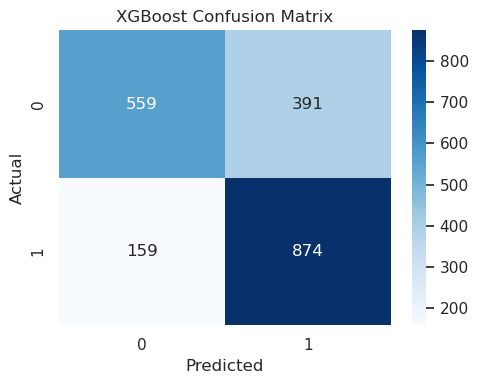

In [42]:
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=random_state,
    n_jobs=-1,
)
xgb_model.fit(X_train_full, y_train_full)

xgb_test_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_test_pred = (xgb_test_pred_proba >= xgb_best_threshold).astype(int)

xgb_metrics = {
    "accuracy": accuracy_score(y_test, xgb_test_pred),
    "precision": precision_score(y_test, xgb_test_pred, zero_division=0),
    "recall": recall_score(y_test, xgb_test_pred, zero_division=0),
    "f1": f1_score(y_test, xgb_test_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, xgb_test_pred_proba),
}
xgb_metrics_df = pd.DataFrame(xgb_metrics, index=["test"]).T.rename(columns={"test": "value"})
display(xgb_metrics_df)

xgb_cm = confusion_matrix(y_test, xgb_test_pred)
xgb_cm_df = pd.DataFrame(xgb_cm, index=class_names, columns=class_names)
display(xgb_cm_df)

plt.figure(figsize=(5, 4))
sns.heatmap(xgb_cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [43]:
xgb_prediction_result = X_test.copy()
xgb_prediction_result["actual"] = y_test_raw.values
xgb_prediction_result["prediction"] = label_encoder.inverse_transform(xgb_test_pred)
xgb_prediction_result["prediction_proba"] = xgb_test_pred_proba

display(xgb_prediction_result.head())


,average_duration_of_resolution,balance_trade_ratio_log1p,credit_history_length,delinquency_trade_ratio_log1p,delinquency_trade_sum_log1p,estimate_of_risk,estimate_of_risk_is_special_9,high_ratio_bank_share_log1p,illegal_trade_gap,inquiry_pressure_log1p,maximum_illegal_trades,maximum_illegal_trades_over_last_year,months_since_first_trade,months_since_first_trade_is_special_8,months_since_last_illegal_trade_is_special_7,months_since_last_illegal_trade_is_special_8,months_since_last_illegal_trade_log1p,months_since_last_inquiry_not_recent_is_special_7,months_since_last_inquiry_not_recent_is_special_8,months_since_last_inquiry_not_recent_log1p,months_since_last_trade_log1p,net_fraction_of_installment_burden,net_fraction_of_installment_burden_is_special_8,net_fraction_of_revolving_burden,net_fraction_of_revolving_burden_is_special_8,nr_banks_with_high_ratio_is_special_8,nr_banks_with_high_ratio_log1p,nr_inquiries_in_last_6_months_log1p,nr_inquiries_in_last_6_months_not_recent_log1p,nr_installment_trades_with_balance_is_special_8,nr_installment_trades_with_balance_log1p,nr_revolving_trades_with_balance_is_special_8,nr_revolving_trades_with_balance_log1p,nr_total_trades,nr_trades_initiated_in_last_year_log1p,nr_trades_insolvent_for_over_60_days_log1p,nr_trades_insolvent_for_over_90_days_log1p,number_of_satisfactory_trades,percentage_of_installment_trades,percentage_of_legal_trades,percentage_trades_with_balance,percentage_trades_with_balance_is_special_8,recent_activity_gap,recent_inquiry_share,revolving_installment_burden_gap,satisfactory_trade_ratio_log1p,actual,prediction,prediction_proba
0,73.0,0.287682,162.0,0.287682,1.098612,51.0,0,0.000000,2.0,0.000000,4.0,2.0,162.0,0,0,0,0.693147,0,0,0.00000,3.583519,11.0,0,43.0,0,0,0.000000,0.000000,0.000000,0,0.693147,0,0.693147,6.0,0.000000,0.693147,0.693147,4.0,33.0,50.0,50.0,0,127.0,0.0,32.0,0.510826,1,1,0.739433
1,111.0,0.092373,364.0,0.000000,0.000000,79.0,0,0.031749,1.0,0.000000,8.0,7.0,364.0,0,1,0,0.000000,0,1,0.00000,3.583519,51.0,0,93.0,0,0,0.693147,0.000000,0.000000,0,1.098612,0,0.693147,31.0,0.000000,0.000000,0.000000,22.0,27.0,100.0,75.0,0,329.0,0.0,42.0,0.536305,0,0,0.101104
2,84.0,0.274437,199.0,0.100083,1.098612,72.0,0,0.000000,-4.0,0.146603,2.0,6.0,199.0,0,0,0,3.583519,0,0,0.00000,0.000000,74.0,1,10.0,0,0,0.000000,1.386294,1.386294,1,1.098612,0,1.609438,19.0,1.386294,0.693147,0.693147,15.0,47.0,94.0,56.0,0,199.0,1.0,-64.0,0.581922,0,1,0.604490
3,91.0,0.133531,275.0,0.000000,0.000000,79.0,0,0.000000,2.0,0.000000,6.0,4.0,275.0,0,0,0,1.945910,0,0,1.94591,0.000000,74.0,1,0.0,0,0,0.000000,0.000000,0.000000,0,0.693147,0,0.693147,14.0,1.386294,0.000000,0.000000,13.0,29.0,86.0,33.0,0,275.0,0.0,-74.0,0.656780,0,1,0.416362
4,109.0,0.336472,264.0,0.000000,0.000000,61.0,0,0.205852,0.0,0.028171,6.0,6.0,264.0,0,0,0,2.564949,0,0,0.00000,3.496508,74.0,0,86.0,0,0,2.197225,0.693147,0.693147,0,1.386294,0,2.484907,35.0,0.000000,0.000000,0.000000,30.0,37.0,97.0,93.0,0,232.0,1.0,12.0,0.619039,1,1,0.860360


## XGBoost の SHAP 確認


,feature,mean_abs_shap,role,description
0,estimate_of_risk,0.511195,base_numeric,申込者の信用リスクの推定スコア。大きいほど低リスク寄りと解釈されることが多いです。
1,months_since_last_inquiry_not_recent_log1p,0.262554,log_numeric,months_since_last_inquiry_not_recent に対して log1...
2,net_fraction_of_revolving_burden,0.227065,base_numeric,リボルビング型口座の負担度合いを表す比率的な指標です。
3,average_duration_of_resolution,0.220879,base_numeric,口座や取引の平均継続期間を表す指標です。
4,percentage_of_legal_trades,0.210102,base_numeric,重大な問題のない正常取引の割合。
5,percentage_of_installment_trades,0.162348,base_numeric,分割払い型取引の割合。
6,high_ratio_bank_share_log1p,0.106224,log_numeric,high_ratio_bank_share に対して log1p 変換を適用した列。
7,number_of_satisfactory_trades,0.094793,base_numeric,問題なく維持されている取引口座の件数。
8,months_since_last_inquiry_not_recent_is_special_8,0.084906,special_value_flag,months_since_last_inquiry_not_recent が特殊値 -8 を...
9,inquiry_pressure_log1p,0.082017,log_numeric,inquiry_pressure に対して log1p 変換を適用した列。


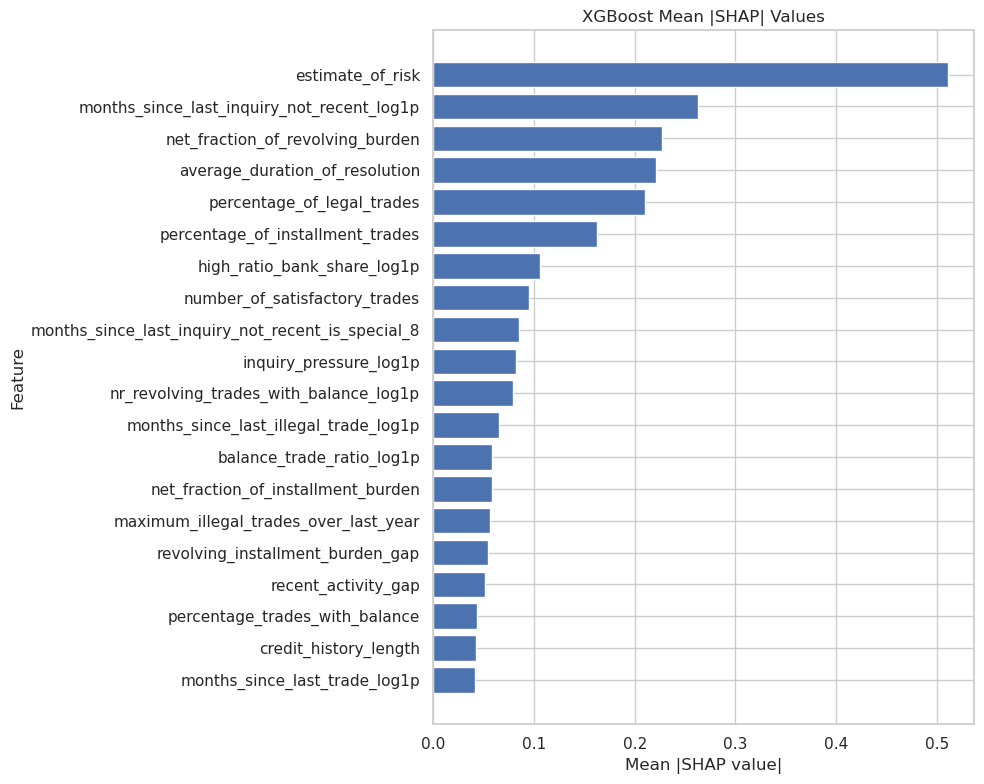

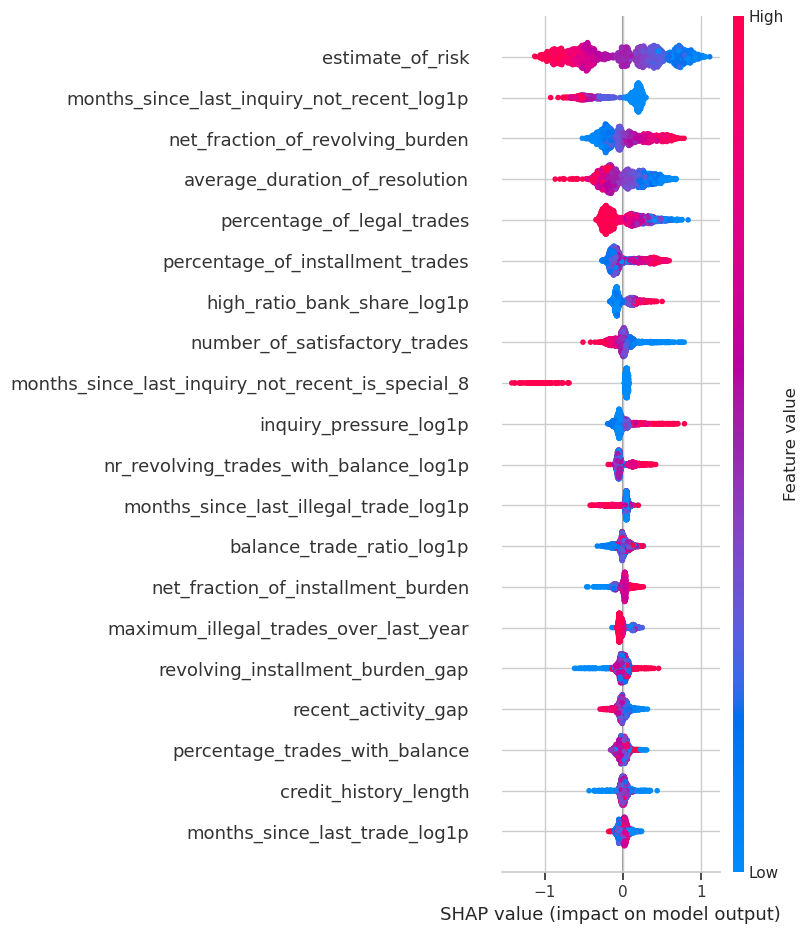

In [44]:
if shap is None:
    raise ImportError("shap is not installed. Install shap in this kernel before running the SHAP section.")

xgb_shap_sample_size = min(2000, len(X_test))
xgb_shap_input = X_test.sample(n=xgb_shap_sample_size, random_state=random_state).copy()

xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap_values = xgb_explainer.shap_values(xgb_shap_input)

xgb_importance_df = (
    pd.DataFrame({"feature": feature_cols, "mean_abs_shap": np.abs(xgb_shap_values).mean(axis=0)})
    .merge(feature_metadata_df[["feature", "role", "description"]], on="feature", how="left")
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

display(xgb_importance_df.head(20))

plot_importance_df = xgb_importance_df.head(20).sort_values("mean_abs_shap", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(plot_importance_df["feature"], plot_importance_df["mean_abs_shap"], color="#4c72b0")
plt.title("XGBoost Mean |SHAP| Values")
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

shap.summary_plot(xgb_shap_values, xgb_shap_input, plot_type="dot", max_display=20)


## モデル artifact の保存


In [45]:
logistic_artifact = {
    "model": logistic_model,
    "scaler": scaler,
    "feature_cols": feature_cols,
    "target_col": target_col,
    "class_names": class_names,
    "class_mapping": class_mapping,
    "best_threshold": logistic_best_threshold,
    "preprocess_summary": preprocess_summary,
}

logistic_artifact_path = MODEL_DIR / "heloc_logistic_artifact.joblib"
joblib.dump(logistic_artifact, logistic_artifact_path)

print(f"saved logistic artifact to: {logistic_artifact_path}")

if XGBClassifier is not None:
    xgb_artifact = {
        "model": xgb_model,
        "scaler": None,
        "feature_cols": feature_cols,
        "target_col": target_col,
        "class_names": class_names,
        "class_mapping": class_mapping,
        "best_threshold": xgb_best_threshold,
        "preprocess_summary": preprocess_summary,
    }
    xgb_artifact_path = MODEL_DIR / "heloc_xgb_artifact.joblib"
    joblib.dump(xgb_artifact, xgb_artifact_path)
    print(f"saved xgboost artifact to: {xgb_artifact_path}")


saved logistic artifact to: /home/kohei/WorkSpace/blog/01.Counterfactual_Analysis/model/heloc_logistic_artifact.joblib
saved xgboost artifact to: /home/kohei/WorkSpace/blog/01.Counterfactual_Analysis/model/heloc_xgb_artifact.joblib
